# Installing required Libraries




In [ ]:
print("Installing required libraries...")
!pip install -q tensorflow tensorflow_model_optimization scikit-learn matplotlib seaborn mediapipe opencv-python
print("Installation complete.")

Installing required libraries...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 476.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 5.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
thinc 

In [ ]:
!pip uninstall -y numpy
!pip install numpy
import os
os.kill(os.getpid(), 9)  # This restarts the Colab runtime

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 302.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 33.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-model-optimization 0.8.0 requires numpy~=1.23, but you have numpy 2.3.2 which is incompatible.
mediapipe 0.10.21 requires numpy<2, but you have numpy 2.3.2 which is incompatible.
cupy-cuda12x 13.3.0 requires numpy<2.3,>=1.22, but you have numpy 2.3.2 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.2 which is incompatible.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1

# Importing Libraries for loading Tranformers.keras
  

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
import tensorflow_model_optimization as tfmot
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from tqdm.notebook import tqdm
from tensorflow.keras import layers, models
import timeit

# Defining Class Positional Encoding before loading Transformers.keras


In [ ]:
@tf.keras.utils.register_keras_serializable(package="custom")
class PositionalEncodingLayer(layers.Layer):
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        self.d_model = d_model
        self.pos_encoding = self._positional_encoding(seq_len, d_model)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"seq_len": self.seq_len, "d_model": self.d_model})
        return cfg

    @classmethod
    def from_config(cls, config):
        return cls(**config)

    def _positional_encoding(self, seq_len, d_model):
        pos = tf.range(seq_len, dtype=tf.float32)[:, tf.newaxis]
        i = tf.range(d_model, dtype=tf.float32)[tf.newaxis, :]
        angle = 1 / tf.pow(10000.0, (2 * (i // 2)) / tf.cast(d_model, tf.float32))
        angle = pos * angle
        sines = tf.sin(angle[:, 0::2])
        coses = tf.cos(angle[:, 1::2])
        encoding = tf.concat([sines, coses], axis=-1)
        return encoding[tf.newaxis, ...]

    def call(self, inputs):
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]


# Load and split the data



In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from tensorflow.keras.models import load_model
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Define gesture classes
CLASSES = ['Afternoon', 'Apple', 'April', 'August', 'Banana', 'Day', 'December', 'Evening',
           'Febraury', 'Friday', 'Grapes', 'January', 'July', 'June', 'March', 'May', 'Monday',
           'Morning', 'Night', 'November', 'October', 'Orange', 'Rainy', 'Saturday', 'September',
           'Summer', 'Sunday', 'Thursday', 'Tuesday', 'Valencia_Orange', 'Watermelon', 'Wednesday', 'Winter']
num_classes = len(CLASSES)

# Load and split data (70% train, 10% val, 20% test)
X = np.load('X_195_75.npy')
y = np.load('y_195_75.npy')

# Check for NaN or inf in input data
if np.any(np.isnan(X)) or np.any(np.isinf(X)):
    raise ValueError("Input X contains NaN or inf values. Please preprocess the data.")

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (1623, 75, 195) (1623,)
Validation shape: (232, 75, 195) (232,)
Test shape: (464, 75, 195) (464,)


# Normalize validation and test sets and load the pre-trained models

In [ ]:
# Normalize validation and test sets (refit scaler on X_train)
scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, X_train.shape[-1]))
X_val = scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

# Check for NaN or inf after normalization
if np.any(np.isnan(X_val)) or np.any(np.isinf(X_val)):
    raise ValueError("Normalized X_val contains NaN or inf values.")
if np.any(np.isnan(X_test)) or np.any(np.isinf(X_test)):
    raise ValueError("Normalized X_test contains NaN or inf values.")

# Save the new scaler for future use
joblib.dump(scaler, 'scaler_new.pkl')  # always download this scaler_new.pkl

# Load pre-trained models
lstm_model = load_model('/content/KSL_LSTM.keras')
transformer_model = load_model('/content/KSL_transformer.keras')
bi_lstm_model = load_model('/content/KSL_BiLSTM.keras')



# Generate validation predictions with k-fold and test predictions

In [ ]:
# Generate validation predictions with k-fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
meta_features_val = np.zeros((X_val.shape[0], 33 * 3))  # 33 classes * 3 models

for fold, (train_idx, val_idx) in enumerate(kf.split(X_val)):
    X_train_fold, X_val_fold = X_val[train_idx], X_val[val_idx]
    lstm_pred = lstm_model.predict(X_val_fold, verbose=0)
    transformer_pred = transformer_model.predict(X_val_fold, verbose=0)
    bi_lstm_pred = bi_lstm_model.predict(X_val_fold, verbose=0)
    meta_features_val[val_idx] = np.hstack((lstm_pred, transformer_pred, bi_lstm_pred))

    # Check for NaN in predictions
    if np.any(np.isnan(lstm_pred)) or np.any(np.isnan(transformer_pred)) or np.any(np.isnan(bi_lstm_pred)):
        print(f"Warning: NaN detected in fold {fold+1} predictions (LSTM: {np.any(np.isnan(lstm_pred))}, Transformer: {np.any(np.isnan(transformer_pred))}, BiLSTM: {np.any(np.isnan(bi_lstm_pred))})")

# Generate test predictions
lstm_pred_test = lstm_model.predict(X_test, verbose=0)
transformer_pred_test = transformer_model.predict(X_test, verbose=0)
bi_lstm_pred_test = bi_lstm_model.predict(X_test, verbose=0)
meta_features_test = np.hstack((lstm_pred_test, transformer_pred_test, bi_lstm_pred_test))

# Check for NaN in test predictions
if np.any(np.isnan(meta_features_test)):
    print("Warning: NaN detected in test predictions")

# Impute NaN in meta-features
imputer = SimpleImputer(strategy='mean')
meta_features_val = imputer.fit_transform(meta_features_val)
meta_features_test = imputer.transform(meta_features_test)

# Verify no NaN remains
if np.any(np.isnan(meta_features_val)) or np.any(np.isnan(meta_features_test)):
    raise ValueError("Imputation failed to remove NaN values")


In [6]:
# Compute class weights for meta-model
class_weights = compute_class_weight('balanced', classes=np.unique(y_val), y=y_val)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights for meta-model:", dict(zip(CLASSES, class_weights)))

# Step 8: Train meta-model
meta_model = LogisticRegression(multi_class='multinomial', max_iter=1000, class_weight=class_weight_dict, random_state=42)
meta_model.fit(meta_features_val, y_val)



Class weights for meta-model: {'Afternoon': np.float64(1.0043290043290043), 'Apple': np.float64(1.1717171717171717), 'April': np.float64(1.0043290043290043), 'August': np.float64(1.0043290043290043), 'Banana': np.float64(1.1717171717171717), 'Day': np.float64(1.0043290043290043), 'December': np.float64(1.0043290043290043), 'Evening': np.float64(1.0043290043290043), 'Febraury': np.float64(1.0043290043290043), 'Friday': np.float64(1.0043290043290043), 'Grapes': np.float64(1.0043290043290043), 'January': np.float64(1.0043290043290043), 'July': np.float64(1.0043290043290043), 'June': np.float64(1.0043290043290043), 'March': np.float64(1.0043290043290043), 'May': np.float64(1.0043290043290043), 'Monday': np.float64(1.0043290043290043), 'Morning': np.float64(1.0043290043290043), 'Night': np.float64(1.0043290043290043), 'November': np.float64(1.0043290043290043), 'October': np.float64(0.8787878787878788), 'Orange': np.float64(1.0043290043290043), 'Rainy': np.float64(1.0043290043290043), 'Satu

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight={0: np.float64(1.0043290043290043),
                                 1: np.float64(1.1717171717171717),
                                 2: np.float64(1.0043290043290043),
                                 3: np.float64(1.0043290043290043),
                                 4: np.float64(1.1717171717171717),
                                 5: np.float64(1.0043290043290043),
                                 6: np.float64(1.0043290043290043),
                                 7: np.float64(1.0043290043290043),
                                 8: np.float64(1.0043290043290043),
                                 9: np.float64(1.00432...
                                 21: np.float64(1.0043290043290043),
                                 22: np.float64(1.0043290043290043),
                                 23: np.float64(1.1717171717171717),
                                 24: np.float64(1.0043290043290043),
                                 25: np.float64(0.8787878787878788),
                                 26: np.float64(1.0043290043290043),
                                 27: np.float64(1.0043290043290043),
                                 28: np.float64(1.0043290043290043),
                                 29: np.float64(1.0043290043290043), ...},
                   max_iter=1000, multi_class='multinomial', random_state=42)

# Evaluate the meta-model

In [10]:
# Evaluate
final_predictions = meta_model.predict(meta_features_test)
accuracy = accuracy_score(y_test, final_predictions)
f1 = f1_score(y_test, final_predictions, average='weighted')
print(f"Stacking Ensemble Accuracy: {accuracy:.4f}")
print(f"Stacking Ensemble Weighted F1-Score: {f1:.4f}")

# Generate the classification report as a dictionary
report = classification_report(y_test, final_predictions, output_dict=True)

# Print the full classification report
print("\nClassification Report:")
print(classification_report(y_test, final_predictions))

# Print macro, micro, and weighted average metrics
print("\nAverages:")
print("  Macro Average:")
print(f"    Precision: {report['macro avg']['precision']:.4f}")
print(f"    Recall: {report['macro avg']['recall']:.4f}")
print(f"    F1-score: {report['macro avg']['f1-score']:.4f}")
print(f"    Support: {report['macro avg']['support']}")

print("\n  Micro Average:")
print(f"    Precision: {report['accuracy']:.4f}")  # Micro average precision is accuracy
print(f"    Recall: {report['accuracy']:.4f}")     # Micro average recall is accuracy
print(f"    F1-score: {report['accuracy']:.4f}")     # Micro average F1-score is accuracy
print(f"    Support: {report['macro avg']['support']}")  # Total number of samples

print("\n  Weighted Average:")
print(f"    Precision: {report['weighted avg']['precision']:.4f}")
print(f"    Recall: {report['weighted avg']['recall']:.4f}")
print(f"    F1-score: {report['weighted avg']['f1-score']:.4f}")
print(f"    Support: {report['weighted avg']['support']}")

Stacking Ensemble Accuracy: 0.9784
Stacking Ensemble Weighted F1-Score: 0.9784

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00        13
           4       0.93      1.00      0.96        13
           5       1.00      1.00      1.00        13
           6       1.00      1.00      1.00        15
           7       0.92      0.92      0.92        13
           8       0.93      0.93      0.93        14
           9       1.00      1.00      1.00        14
          10       1.00      1.00      1.00        15
          11       1.00      1.00      1.00        14
          12       1.00      1.00      1.00        15
          13       1.00      1.00      1.00        14
          14       1.00      0.93      0.96        14
          15       1.00      0.9

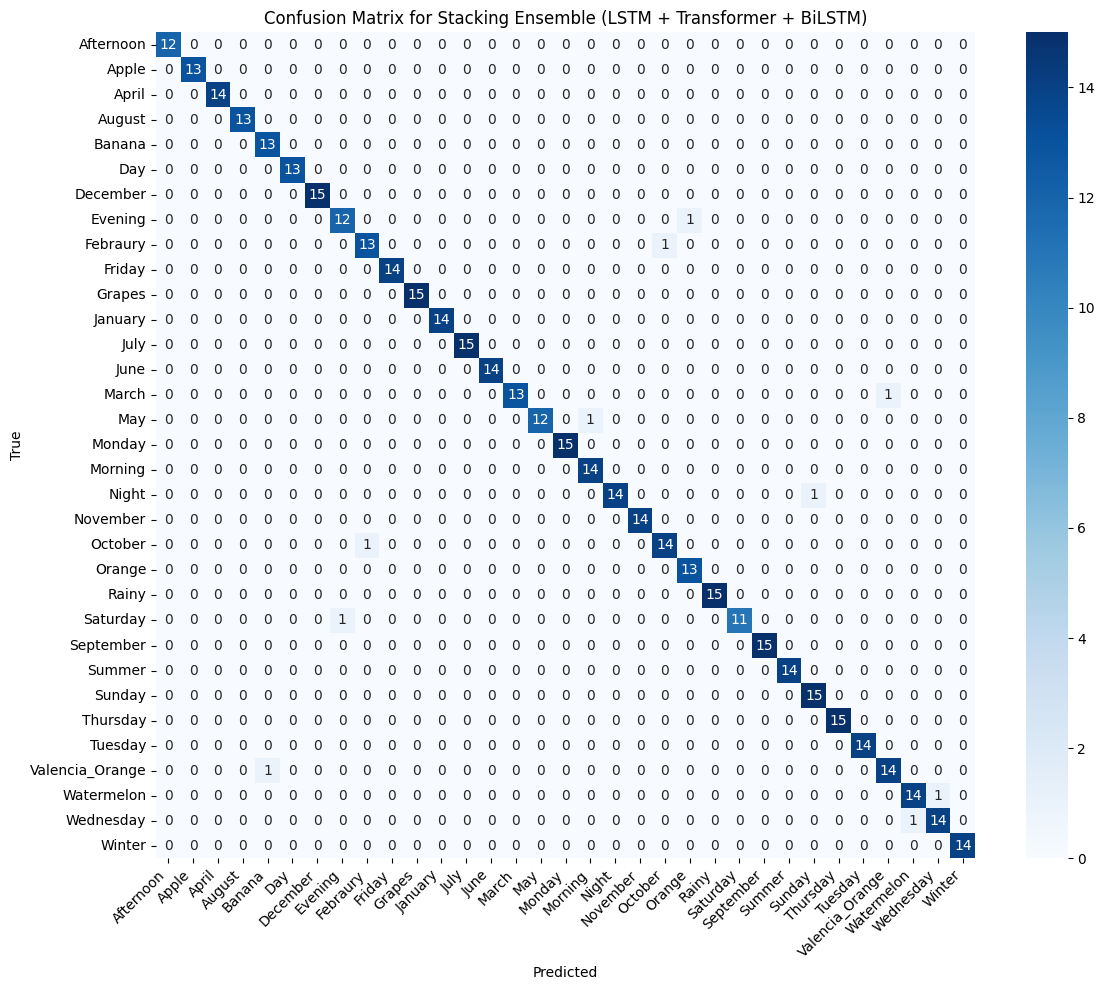

In [11]:
# Confusion matrix
cm = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix for Stacking Ensemble (LSTM + Transformer + BiLSTM)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Save the meta-model in .keras

In [12]:
# Save meta-model
joblib.dump(meta_model, 'meta_model_lstm_transformer_bilstm.keras')
print("meta-model successfully saved ")

meta-model successfully saved 
